# 03_01 · Modelos — AI4I Predictive Maintenance


In [3]:
import pickle
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score
from sklearn.model_selection import LeaveOneOut, cross_val_predict
import warnings; warnings.filterwarnings('ignore')

with open('../data/processed/splits.pkl', 'rb') as f:
    splits = pickle.load(f)

X_train, X_test, y_train, y_test = splits['ai4i']


## 1. AI4I — Regresión Logística (baseline lineal)

La Regresión Logística es el punto de partida más sencillo.

Con `class_weight='balanced'`, scikit-learn pondera automáticamente cada muestra
inversamente proporcional a la frecuencia de su clase: las 339 muestras de fallo
tienen peso ~29× mayor que las normales. Esto equilibra la función de pérdida
sin necesidad de oversampling.

> **Qué esperamos:** Recall alto (el modelo aprende que los fallos son más importantes)
> pero Precision baja (muchas alarmas falsas porque la frontera lineal es muy amplia).


In [2]:
lr = LogisticRegression(class_weight='balanced', random_state=42, max_iter=1000)
lr.fit(X_train, y_train)
print(classification_report(y_test, lr.predict(X_test), target_names=['Normal', 'Fallo']))
print(f'ROC-AUC: {roc_auc_score(y_test, lr.predict_proba(X_test)[:,1]):.4f}')


              precision    recall  f1-score   support

      Normal       1.00      0.86      0.92      1932
       Fallo       0.18      0.90      0.30        68

    accuracy                           0.86      2000
   macro avg       0.59      0.88      0.61      2000
weighted avg       0.97      0.86      0.90      2000

ROC-AUC: 0.9379


## 2. AI4I — Random Forest

Random Forest es un ensemble de árboles de decisión independientes:
- Cada árbol se entrena en un bootstrap del dataset (muestreo con reemplazo)
- Cada split considera solo un subconjunto aleatorio de features
- La predicción es la media de las probabilidades de todos los árboles

Con `class_weight='balanced'`, cada árbol compensa el desbalanceo en su bootstrap.

> **Qué esperamos:** mejor Precision que Regresión Logística (los árboles capturan
> relaciones no lineales), pero posiblemente menor Recall.


In [3]:
rf = RandomForestClassifier(n_estimators=200, class_weight='balanced',
                             random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
print(classification_report(y_test, rf.predict(X_test), target_names=['Normal', 'Fallo']))
print(f'ROC-AUC: {roc_auc_score(y_test, rf.predict_proba(X_test)[:,1]):.4f}')


              precision    recall  f1-score   support

      Normal       0.99      1.00      0.99      1932
       Fallo       0.96      0.71      0.81        68

    accuracy                           0.99      2000
   macro avg       0.97      0.85      0.90      2000
weighted avg       0.99      0.99      0.99      2000

ROC-AUC: 0.9734


## 3. AI4I — XGBoost

XGBoost es gradient boosting: construye árboles **secuencialmente**, donde cada árbol
corrige los errores del anterior. Es más potente que RF pero más sensible al tuning.

`scale_pos_weight = (nº negativos) / (nº positivos) ≈ 28.5` equivale a decirle al modelo
que cada fallo pesa 28.5 veces más que una muestra normal en la función de pérdida.
Es el equivalente de `class_weight='balanced'` para XGBoost.

> **Qué esperamos:** mejor AUC que RF (boosting suele superar bagging en tabular data).


In [4]:
try:
    from xgboost import XGBClassifier
    scale_pos = (y_train == 0).sum() / (y_train == 1).sum()
    xgb = XGBClassifier(scale_pos_weight=scale_pos, n_estimators=200,
                         random_state=42, eval_metric='logloss', verbosity=0)
    xgb.fit(X_train, y_train)
    print(classification_report(y_test, xgb.predict(X_test), target_names=['Normal', 'Fallo']))
    print(f'ROC-AUC: {roc_auc_score(y_test, xgb.predict_proba(X_test)[:,1]):.4f}')
except ImportError:
    print('XGBoost no instalado: pip install xgboost')


              precision    recall  f1-score   support

      Normal       0.99      0.99      0.99      1932
       Fallo       0.84      0.84      0.84        68

    accuracy                           0.99      2000
   macro avg       0.92      0.92      0.92      2000
weighted avg       0.99      0.99      0.99      2000

ROC-AUC: 0.9800


## 4. AI4I — LightGBM

LightGBM es una implementación de gradient boosting optimizada por Microsoft:
- **Leaf-wise growth** (vs level-wise de XGBoost): más eficiente con datos desbalanceados
- **GOSS** (Gradient-based One-Side Sampling): muestrea las instancias con mayor gradiente
  → las instancias de fallo (gradiente alto) se muestrean más → mejor manejo del desbalanceo

Usamos el mismo `scale_pos_weight` que XGBoost para comparabilidad.

> **Qué esperamos:** rendimiento similar a XGBoost, pero más rápido en el tuning posterior.


In [5]:
try:
    from lightgbm import LGBMClassifier
    scale_pos = (y_train == 0).sum() / (y_train == 1).sum()
    lgbm = LGBMClassifier(scale_pos_weight=scale_pos, n_estimators=200,
                          random_state=42, verbose=-1)
    lgbm.fit(X_train, y_train)
    print(classification_report(y_test, lgbm.predict(X_test), target_names=["Normal", "Fallo"]))
    print(f"ROC-AUC: {roc_auc_score(y_test, lgbm.predict_proba(X_test)[:,1]):.4f}")
except ImportError:
    print("LightGBM no instalado: pip install lightgbm")
    lgbm = None


              precision    recall  f1-score   support

      Normal       0.99      1.00      1.00      1932
       Fallo       0.95      0.84      0.89        68

    accuracy                           0.99      2000
   macro avg       0.97      0.92      0.94      2000
weighted avg       0.99      0.99      0.99      2000

ROC-AUC: 0.9734


## 5. AI4I — SVM (Support Vector Machine)

El SVM con kernel RBF construye una **frontera de decisión no lineal** en el espacio
transformado por el kernel. Es conceptualmente diferente a los árboles:
- Los árboles dividen el espacio con hiperplanos paralelos a los ejes
- El SVM crea elipsoides y curvas en el espacio original

Con `class_weight='balanced'` el margen de separación se ponderará para dar
más importancia a los fallos.

> **Qué esperamos:** AUC competitivo pero quizás peor F1 (el SVM sin calibrar
> puede no dar buenas probabilidades con datos tan desbalanceados).


In [6]:
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

svm = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", SVC(class_weight="balanced", probability=True, random_state=42))
])
svm.fit(X_train, y_train)
print(classification_report(y_test, svm.predict(X_test), target_names=["Normal", "Fallo"]))
print(f"ROC-AUC: {roc_auc_score(y_test, svm.predict_proba(X_test)[:,1]):.4f}")


              precision    recall  f1-score   support

      Normal       1.00      0.93      0.96      1932
       Fallo       0.31      0.93      0.46        68

    accuracy                           0.93      2000
   macro avg       0.65      0.93      0.71      2000
weighted avg       0.97      0.93      0.94      2000

ROC-AUC: 0.9702


## 6. Comparativa de modelos — AI4I

Construimos una tabla única con Precision, Recall, F1 y ROC-AUC para todos los modelos.

**Cómo interpretar:**
- **Recall** es la métrica principal — buscamos > 0.85
- **F1** equilibra Precision y Recall — útil para comparar modelos con distinto trade-off
- **ROC-AUC** mide la separabilidad global independientemente del umbral — indica el potencial máximo
- El umbral por defecto (0.5) favorece a los modelos con buena calibración; en notebooks
  posteriores ajustaremos el umbral para maximizar F1 con Recall ≥ 0.85


              Precision(fallo)  Recall(fallo)  F1(fallo)  ROC-AUC
Modelo                                                           
XGBoost                 0.8382         0.8382     0.8382   0.9800
RandomForest            0.9600         0.7059     0.8136   0.9734
LightGBM                0.9500         0.8382     0.8906   0.9734
SVM                     0.3058         0.9265     0.4599   0.9702
LogReg                  0.1810         0.8971     0.3012   0.9379


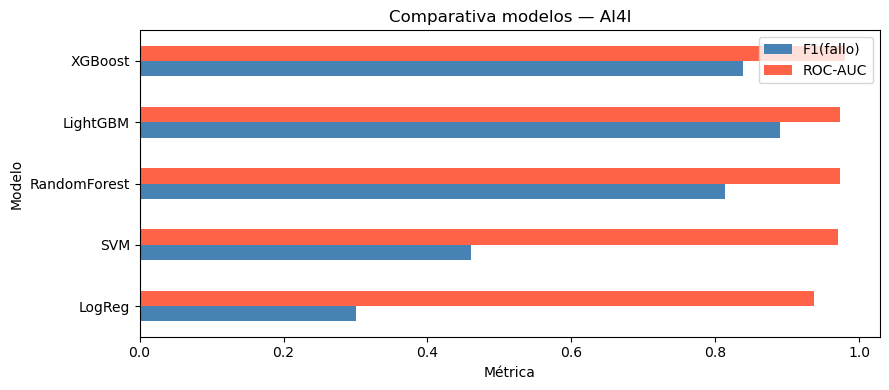

In [7]:
import matplotlib.pyplot as plt
from sklearn.metrics import f1_score, precision_score, recall_score

candidates = {"LogReg": lr, "RandomForest": rf, "SVM": svm}
try:
    candidates["XGBoost"] = xgb
except NameError: pass
if lgbm is not None:
    candidates["LightGBM"] = lgbm

rows = []
for name, model in candidates.items():
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:,1]
    rows.append({
        "Modelo": name,
        "Precision(fallo)": precision_score(y_test, y_pred),
        "Recall(fallo)": recall_score(y_test, y_pred),
        "F1(fallo)": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_prob),
    })

comp = pd.DataFrame(rows).set_index("Modelo").round(4)
print(comp.sort_values("ROC-AUC", ascending=False).to_string())

comp[["F1(fallo)", "ROC-AUC"]].sort_values("ROC-AUC").plot(
    kind="barh", figsize=(9, 4), color=["steelblue", "tomato"])
plt.title("Comparativa modelos — AI4I")
plt.xlabel("Métrica")
plt.tight_layout()
plt.show()


## 7. Validación cruzada — estabilidad de los modelos

Un único split 80/20 puede tener varianza. Verificamos con **Stratified K-Fold (5 splits)** sobre el conjunto de entrenamiento que los resultados son robustos y no producto de la partición concreta.

La desviación estándar baja confirma que el modelo generaliza de forma estable.

=== CV 5-Fold sobre train — estabilidad ===
              F1 (media)  F1 (±std)  Recall (media)  AUC (media)
Modelo                                                          
RandomForest      0.8531     0.0348          0.7563       0.9752
LightGBM          0.8520     0.0152          0.8080       0.9658
XGBoost           0.8237     0.0166          0.8118       0.9698
SVM               0.4591     0.0233          0.8782       0.9619
LogReg            0.2669     0.0083          0.8304       0.9228


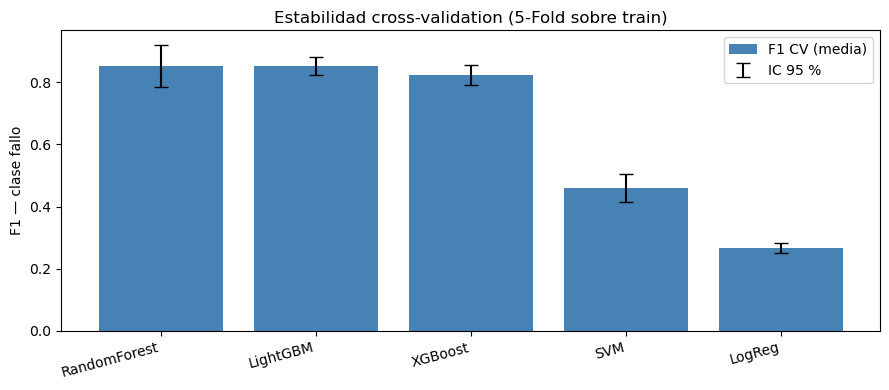


→ Desviación baja confirma que los resultados no dependen del split concreto.


In [8]:
from sklearn.model_selection import cross_validate, StratifiedKFold

cv5 = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_rows = []
for name, model in candidates.items():
    scores = cross_validate(
        model, X_train, y_train,
        cv=cv5,
        scoring={'f1': 'f1', 'recall': 'recall', 'roc_auc': 'roc_auc'},
        n_jobs=-1,
    )
    cv_rows.append({
        'Modelo':          name,
        'F1 (media)':      round(scores['test_f1'].mean(), 4),
        'F1 (±std)':       round(scores['test_f1'].std(), 4),
        'Recall (media)':  round(scores['test_recall'].mean(), 4),
        'AUC (media)':     round(scores['test_roc_auc'].mean(), 4),
    })

df_cv = pd.DataFrame(cv_rows).set_index('Modelo').sort_values('F1 (media)', ascending=False)
print('=== CV 5-Fold sobre train — estabilidad ===')
print(df_cv.to_string())

# Visualizar: comparar F1 test (barra llena) con F1 CV (barra + barra de error)
fig, ax = plt.subplots(figsize=(9, 4))
x = range(len(df_cv))
ax.bar(x, df_cv['F1 (media)'], color='steelblue', label='F1 CV (media)')
ax.errorbar(x, df_cv['F1 (media)'], yerr=df_cv['F1 (±std)'] * 1.96,
            fmt='none', color='black', capsize=5, label='IC 95 %')
ax.set_xticks(x)
ax.set_xticklabels(df_cv.index, rotation=15, ha='right')
ax.set_ylabel('F1 — clase fallo')
ax.set_title('Estabilidad cross-validation (5-Fold sobre train)')
ax.legend()
plt.tight_layout()
plt.show()

print('\n→ Desviación baja confirma que los resultados no dependen del split concreto.')

## 8. Guardar modelos

In [10]:
import os
# Update mode: keep existing tuned models, update only baselines
pkl_path = '../data/processed/models.pkl'
if os.path.exists(pkl_path):
    with open(pkl_path, 'rb') as f:
        existing = pickle.load(f)
else:
    existing = {}

new_models = {'lr': lr, 'rf': rf, 'svm': svm}
try: new_models['xgb'] = xgb
except NameError: pass
if lgbm is not None: new_models['lgbm'] = lgbm

existing.update(new_models)
with open(pkl_path, 'wb') as f:
    pickle.dump(existing, f)
print('Modelos guardados/actualizados:', list(new_models.keys()))

Modelos guardados/actualizados: ['lr', 'rf', 'svm', 'xgb', 'lgbm']
